# Sales Analysis & Profit predictor

### Objective:
To analyze factors affecting profit margin and build a predictive model to estimate profitability.

### Key Questions:
- Which categories are most profitable?
- Does region impact profit?
- Can we predict profit margin based on features?

### Load and Inspect 

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\acer\Desktop\New folder\DA\Portfolio\Superstore\Sample - Superstore.csv", encoding='windows-1252')

print(df.shape)
print(df.columns.tolist())

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

In [83]:
df.dtypes
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [84]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [85]:
print(df['Order Date'].dtype)
print(df['Order Date'].head())

object
0     11/8/2016
1     11/8/2016
2     6/12/2016
3    10/11/2015
4    10/11/2015
Name: Order Date, dtype: object


### Data Cleaning

In [86]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df['Order Date'].dtype)
print(df['Order Date'].head())

datetime64[ns]
0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[ns]


### Feature engineering

In [87]:
df['Ship Days'] = (df['Ship Date']- df['Order Date']).dt.days

In [88]:
print(df['Ship Days'].head(5))

0    3
1    3
2    4
3    7
4    7
Name: Ship Days, dtype: int64


In [89]:
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

In [90]:
df['Profit Margin'] = df['Profit']/df['Sales']

In [91]:
print(df[['Order Date', 'Ship Days', 'Order Month', 'Order Year', 'Profit Margin']].head())

  Order Date  Ship Days  Order Month  Order Year  Profit Margin
0 2016-11-08          3           11        2016         0.1600
1 2016-11-08          3           11        2016         0.3000
2 2016-06-12          4            6        2016         0.4700
3 2015-10-11          7           10        2015        -0.4000
4 2015-10-11          7           10        2015         0.1125


### EDA

#### 1. Which Category makes the most sales and profit?

In [92]:
category_summary = df.groupby('Category')[['Sales','Profit']].sum().reset_index()

In [93]:
print(category_summary)

          Category        Sales       Profit
0        Furniture  741999.7953   18451.2728
1  Office Supplies  719047.0320  122490.8008
2       Technology  836154.0330  145454.9481


### Finding 1
Furniture generates strong sales but the lowest profit by far only $18K on $742K revenue (2.5% margin).
Office Supplies outperforms Furniture in profit despite lower sales volume, suggesting Furniture may be over-discounted or expensive to ship.

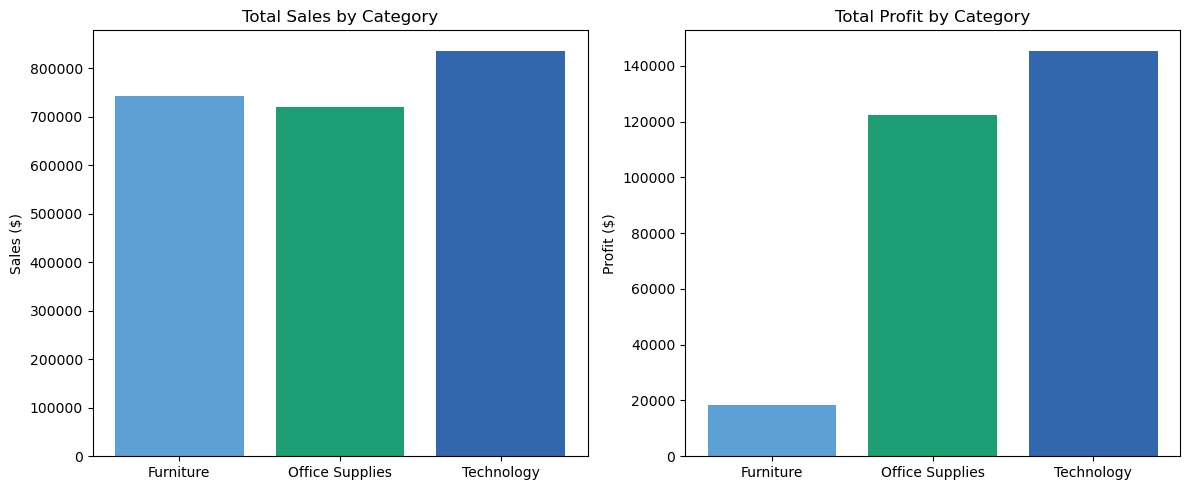

In [94]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].bar(category_summary['Category'], category_summary['Sales'], color=['#5da1d4', '#1d9e75', '#3266ad'])
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Sales ($)')

axes[1].bar(category_summary['Category'], category_summary['Profit'],color=['#5da1d4', '#1d9e75', '#3266ad'])
axes[1].set_title('Total Profit by Category')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()

#### 2. Which Region performs best?

In [95]:
region_summary = df.groupby('Region')[['Sales','Profit']].sum().reset_index()

In [96]:
print(region_summary)

    Region        Sales       Profit
0  Central  501239.8908   39706.3625
1     East  678781.2400   91522.7800
2    South  391721.9050   46749.4303
3     West  725457.8245  108418.4489


### Finding 2
West is the strongest region by both sales and profit.
Central is underperforming on profit relative to its sales volume, suggesting its worth investigating discounting patterns here.
South, however, has lowest sales but has greater profit margins.

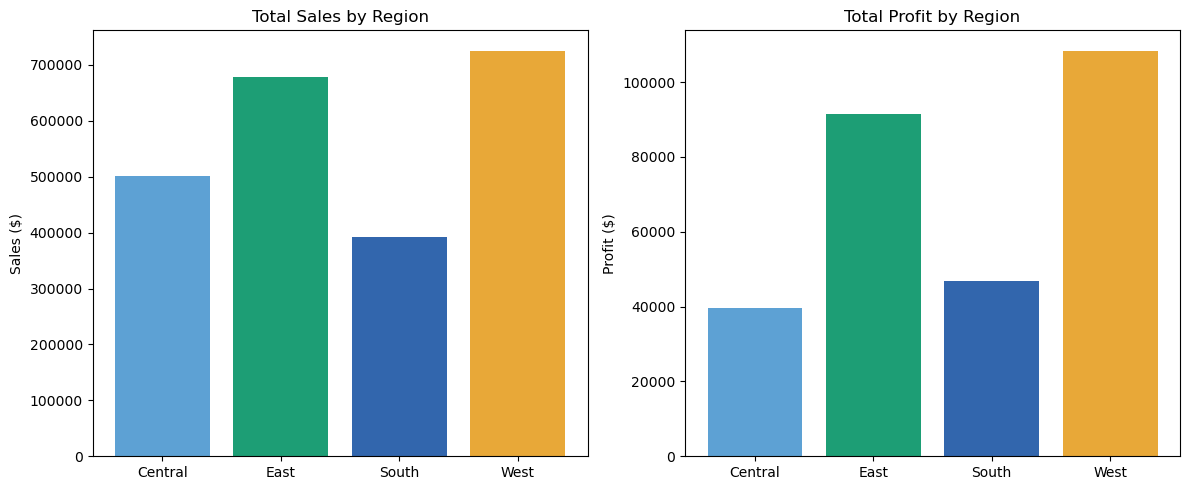

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(region_summary['Region'], region_summary['Sales'], color=['#5da1d4', '#1d9e75', '#3266ad', '#e8a838'])
axes[0].set_title('Total Sales by Region')
axes[0].set_ylabel('Sales ($)')

axes[1].bar(region_summary['Region'], region_summary['Profit'], color=['#5da1d4', '#1d9e75', '#3266ad', '#e8a838'])
axes[1].set_title('Total Profit by Region')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()

### 3. Does discount hurt profile?

In [98]:
df[['Discount', 'Profit']].describe()

,Discount,Profit
count,9994.000000,9994.000000
mean,0.156203,28.656896
std,0.206452,234.260108
min,0.000000,-6599.978000
25%,0.000000,1.728750
50%,0.200000,8.666500
75%,0.200000,29.364000
max,0.800000,8399.976000


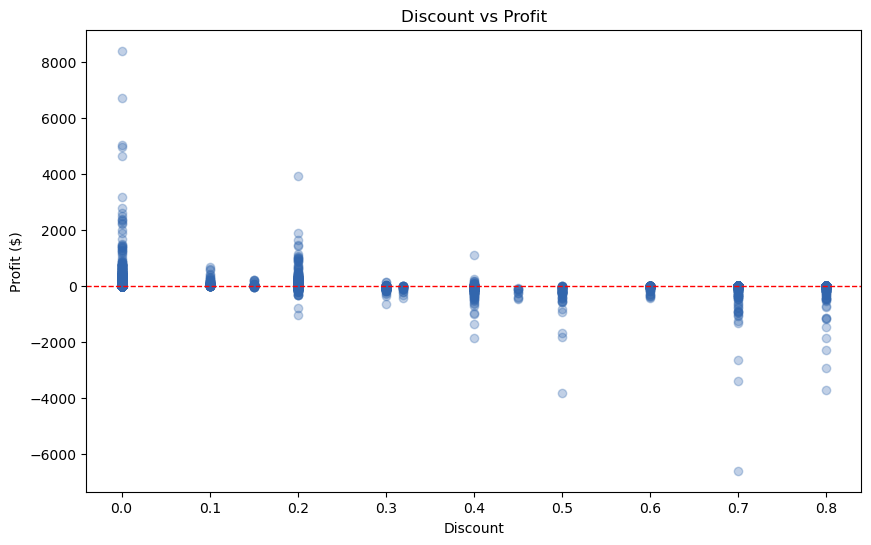

In [99]:
plt.figure(figsize=(10,6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#3266ad')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')

plt.show()

### Finding 3
Discounting is the single biggest threat to profitability.
Orders with discounts above 40% are almost universally unprofitable.
The worst losses (-$6,599) occur at the highest discount levels (70-80%).
This suggests the business needs a strict discount cap policy.

### 4. Sales trend over time

In [100]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Order Year', 'Order Month']].assign(day=1).rename(columns={'Order Year': 'year', 'Order Month': 'month'}))

print(monthly_sales.head())

   Order Year  Order Month      Sales       Date
0        2014            1  14236.895 2014-01-01
1        2014            2   4519.892 2014-02-01
2        2014            3  55691.009 2014-03-01
3        2014            4  28295.345 2014-04-01
4        2014            5  23648.287 2014-05-01


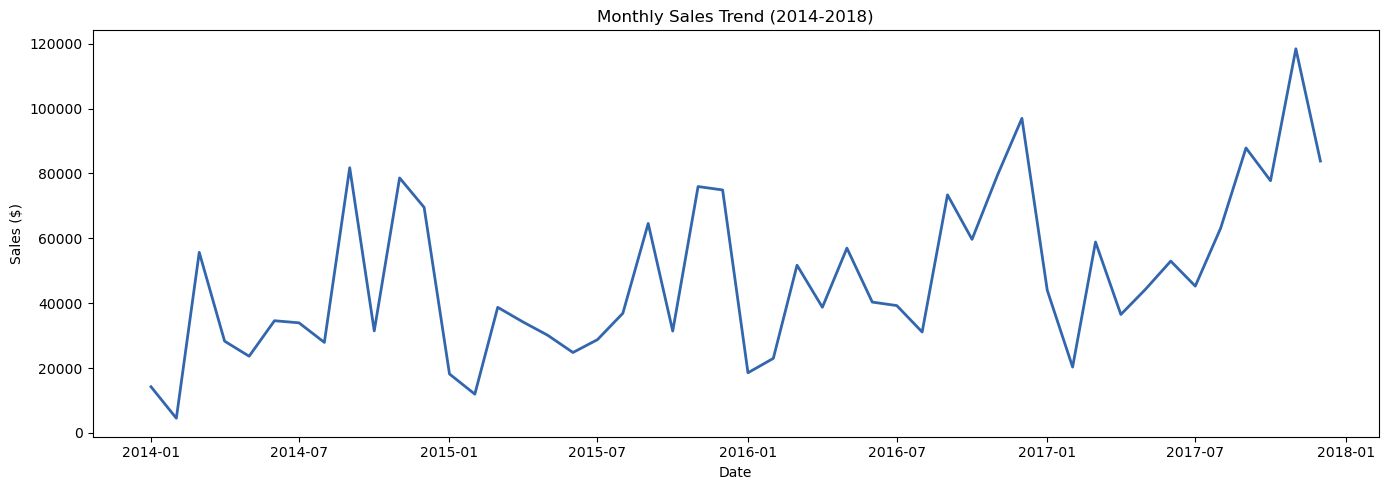

In [101]:
plt.figure(figsize=(14, 5))

plt.plot(monthly_sales['Date'], monthly_sales['Sales'], color='#3266ad', linewidth=2)

plt.title('Monthly Sales Trend (2014-2018)')
plt.xlabel('Date')
plt.ylabel('Sales ($)')

plt.tight_layout()
plt.show()

### Finding 4
Sales show a clear upward trend from 2014 to 2018 which states the business is growing.
Strong seasonality is visible every year but Q4 spikes consistently while
January dips. Operations and inventory should be planned around this cycle.

In [123]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

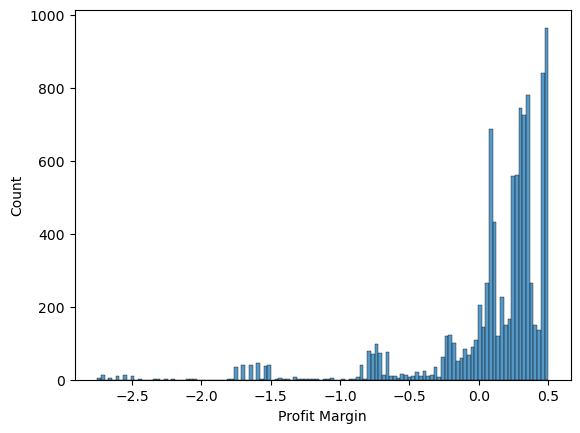

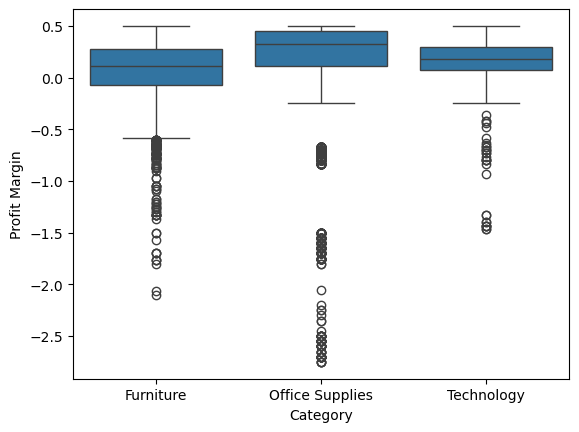

In [124]:
sns.histplot(df['Profit Margin'])
plt.show()

sns.boxplot(x='Category', y='Profit Margin', data=df)
plt.show()

### Insights:

- Profit distribution is concentrated in positive range with a long tail of losses
- Technology category has higher median profit and is more stable
- Furniture shows frequent negative profit margins, indicating consistent underperformance
- Office Supplies has extreme loss outliers, indicating occasional high-risk transactions

### Based on observed variability in profit margins across categories, a predictive model is built to estimate profit margin using available features.

## Profit Indicator - ML Model - Linear Regression 

In [102]:
feature = ['Sales', 'Quantity', 'Discount', 'Category', 'Region', 'Ship Mode']
target = 'Profit'

X = df[feature]
y = df[target]

print(X.shape)
print(y.shape)

(9994, 6)
(9994,)


In [103]:
le = LabelEncoder()

X = X.copy()
X['Category'] = le.fit_transform(X['Category'])
X['Region'] = le.fit_transform(X['Region'])
X['Ship Mode'] = le.fit_transform(X['Ship Mode'])

print(X.head())

      Sales  Quantity  Discount  Category  Region  Ship Mode
0  261.9600         2      0.00         0       2          2
1  731.9400         3      0.00         0       2          2
2   14.6200         2      0.00         1       3          2
3  957.5775         5      0.45         0       2          3
4   22.3680         2      0.20         1       2          3


In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42 )

print('Training rows:', X_train.shape[0])
print('Testing_rows', X_test.shape[0])

Training rows: 7995
Testing_rows 1999


In [105]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE: ${mae:.2f}')
print(f'R2 Score: {r2:.4f}')

MAE: $69.40
R2 Score: -0.7199


## 5. Improving the Model — Random Forest

Linear Regression produced a negative R² score (-0.72), meaning it failed to capture
the relationship between our features and profit.

This is likely because the relationship is non-linear, especially Discount,
which we saw in EDA doesn't affect profit in a straight line but drops off sharply after 40%.

We'll now try Random Forest, a more powerful model that handles non-linear patterns well.

In [106]:
from sklearn.ensemble import RandomForestRegressor

In [107]:
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [108]:
print(f'MAE: ${mae_rf:.2f}')
print(f'R2 Score: {r2_rf:.4f}')

MAE: $32.53
R2 Score: -0.2109


In [109]:
y = df['Profit Margin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model2.fit(X_train, y_train)

y_pred_rf2 = rf_model2.predict(X_test)

mae_rf2 = mean_absolute_error(y_test, y_pred_rf2)
r2_rf2 = r2_score(y_test, y_pred_rf2)

print(f'MAE: {mae_rf2:.4f}')
print(f'R2 Score: {r2_rf2:.4f}')

MAE: 0.0970
R2 Score: 0.9118


In [110]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model2.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

     Feature  Importance
2   Discount    0.868755
0      Sales    0.080834
1   Quantity    0.018434
3   Category    0.014415
5  Ship Mode    0.008996
4     Region    0.008567


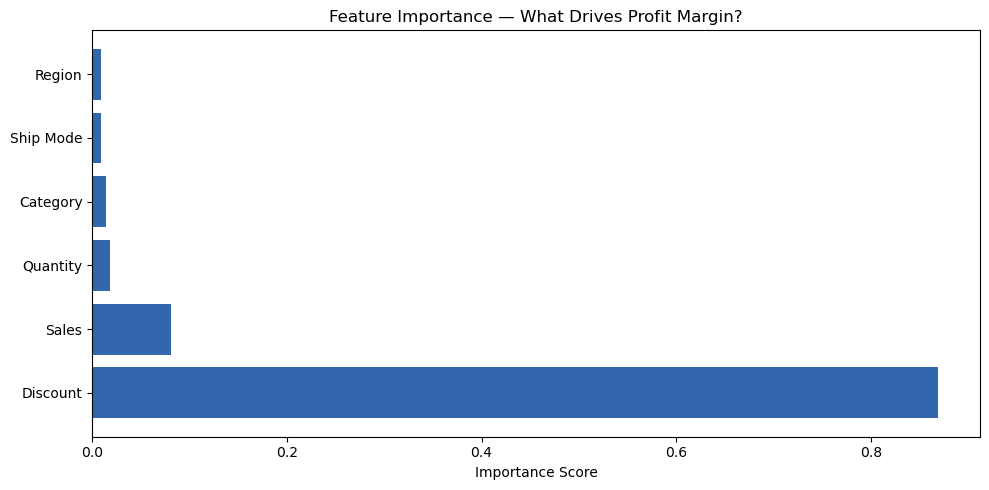

In [111]:
plt.figure(figsize=(10, 5))

plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#3266ad')

plt.title('Feature Importance — What Drives Profit Margin?')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [119]:
le_category = LabelEncoder()
le_region = LabelEncoder()
le_shipmode = LabelEncoder()

X = df[feature].copy()
X['Category'] = le_category.fit_transform(X['Category'])
X['Region'] = le_region.fit_transform(X['Region'])
X['Ship Mode'] = le_shipmode.fit_transform(X['Ship Mode'])

# retrain model with new encoders
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model2.fit(X_train, y_train)

# now predict with readable inputs
new_order = pd.DataFrame({
    'Sales': [500],
    'Quantity': [3],
    'Discount': [0.2],
    'Category': [le_category.transform(['Technology'])[0]],
    'Region': [le_region.transform(['West'])[0]],
    'Ship Mode': [le_shipmode.transform(['Standard Class'])[0]]
})

predicted_margin = rf_model2.predict(new_order)
print(f'Predicted Profit Margin: {predicted_margin[0]:.2%}')

Predicted Profit Margin: 23.39%


## 6. Conclusions

1. **Discount is everything** — it drives 87% of profit margin variation.
   Any discount above 40% almost guarantees a loss.

2. **Furniture is a problem category** — high sales, razor thin margins.
   Needs pricing or cost review.

3. **West region leads** — strongest in both sales and profit.
   Central underperforms on margin despite decent sales volume.

4. **Business is growing** — clear upward sales trend from 2014–2018
   with consistent Q4 seasonality every year.

5. **Model performance** — Random Forest achieved R² = 0.91 predicting
   profit margin, confirming discount rate as the dominant variable.

6. **Profit Margin Predictor** — the trained model can predict margin
   for any new order. Example: a Technology product sold in the West
   with Standard Class shipping and 20% discount is predicted to achieve
   a 23.39% profit margin. Increasing that discount to 50% would
   significantly erode the margin based on patterns learned from
   9,994 historical orders.